# Notebook 04: Modeling - Prédiction des Complications Post-Vaccination/Post-Traitement

## Objectif
Créer et entraîner plusieurs modèles de Machine Learning pour prédire les effets indésirables graves :
- **ML Classique**: XGBoost et Random Forest avec optimisation d'hyperparamètres
- **Graph ML**: GNN amélioré avec meilleure construction du graphe
- **NLP**: BERT avec fine-tuning amélioré
- **Fusion**: Combinaison des modèles avec apprentissage automatique

## Améliorations apportées
- Gestion améliorée du déséquilibre des classes
- Feature engineering étendu
- Optimisation d'hyperparamètres
- GNN avec architecture plus sophistiquée
- BERT avec plus d'époques et fine-tuning
- Fusion avec modèle d'ensemble appris

## Données
Utilisation du dataset `dataset_for_modeling.csv` préparé dans le Notebook 03.

In [1]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, precision_recall_curve, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv, GATConv, SAGEConv, global_mean_pool, global_max_pool
from transformers import BertTokenizer, BertModel, BertForSequenceClassification, Trainer, TrainingArguments
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✅ Toutes les bibliothèques importées avec succès!")

c:\Users\rania\OneDrive\Desktop\rania\datascienceproject\data_science\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Toutes les bibliothèques importées avec succès!


📂 Chargement du dataset...
✅ Dataset chargé: 5423 lignes, 15 colonnes
📊 Colonnes: ['age', 'sex', 'weight_kg', 'bmi', 'n_drugs', 'n_symptoms', 'n_allergies', 'n_chronic_diseases', 'score_risque_interaction', 'vulnerability_score', 'is_high_risk', 'severity_score', 'target_binary', 'target_risk', 'symptoms_text']
🎯 Distribution target_binary: {0: 4514, 1: 909}
📈 Ratio de déséquilibre: 0.201 (positif/négatif)
📊 Pourcentage classe positive: 16.8%


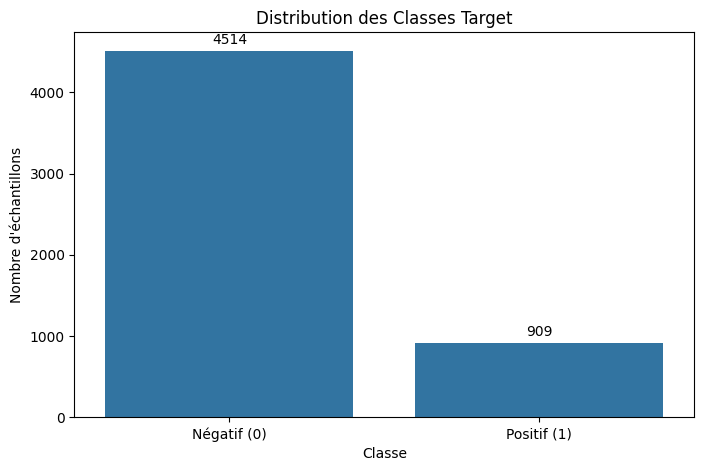

In [2]:
# Chargement et analyse des données
print("📂 Chargement du dataset...")

# Chemin vers le dataset final
data_path = '../data/final/dataset_for_modeling.csv'

# Chargement
df = pd.read_csv(data_path)

print(f"✅ Dataset chargé: {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f"📊 Colonnes: {list(df.columns)}")
print(f"🎯 Distribution target_binary: {df['target_binary'].value_counts().to_dict()}")

# Analyse du déséquilibre
target_counts = df['target_binary'].value_counts()
imbalance_ratio = target_counts[1] / target_counts[0]
print(f"📈 Ratio de déséquilibre: {imbalance_ratio:.3f} (positif/négatif)")
print(f"📊 Pourcentage classe positive: {target_counts[1]/len(df)*100:.1f}%")

# Visualisation de la distribution des classes
plt.figure(figsize=(8, 5))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.title('Distribution des Classes Target')
plt.xlabel('Classe')
plt.ylabel('Nombre d\'échantillons')
plt.xticks([0, 1], ['Négatif (0)', 'Positif (1)'])
for i, v in enumerate(target_counts.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')
plt.show()

In [3]:
# Modèle XGBoost avec optimisation d'hyperparamètres
print("🚀 Optimisation et entraînement du modèle XGBoost...")

# Calcul du poids pour la classe minoritaire
scale_pos_weight = len(y_train_balanced[y_train_balanced == 0]) / len(y_train_balanced[y_train_balanced == 1])

# Grille d'hyperparamètres pour XGBoost
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'scale_pos_weight': [scale_pos_weight, scale_pos_weight * 0.5, scale_pos_weight * 2]
}

# Recherche par grille avec validation croisée
xgb_grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_param_grid,
    cv=3,  # Réduit pour accélérer
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid_search.fit(X_train_balanced, y_train_balanced)

# Meilleurs paramètres
print(f"✅ Meilleurs paramètres XGBoost: {xgb_grid_search.best_params_}")
print(f"✅ Meilleur score CV AUC: {xgb_grid_search.best_score_:.3f}")

# Modèle final avec meilleurs paramètres
xgb_model = xgb_grid_search.best_estimator_

# Prédictions
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Évaluation détaillée
print("\n📊 Résultats XGBoost sur test:")
print(classification_report(y_test, xgb_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.3f}")
print(f"F1-Score: {f1_score(y_test, xgb_pred):.3f}")

# Matrice de confusion améliorée
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, xgb_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matrice de Confusion - XGBoost')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')

# Ajouter les pourcentages
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j + 0.5, i + 0.5, f'\n({cm_normalized[i, j]:.1%})',
                ha='center', va='center', fontsize=10, color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.show()

# Courbe Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, xgb_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='XGBoost')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Precision-Recall - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

🚀 Optimisation et entraînement du modèle XGBoost...


NameError: name 'y_train_balanced' is not defined

In [4]:
# Feature Engineering avancé
print("🔧 Feature Engineering avancé...")

# Features démographiques et médicales de base
base_features = [
    'age', 'weight_kg', 'bmi', 'n_drugs', 'n_symptoms',
    'n_allergies', 'n_chronic_diseases', 'score_risque_interaction',
    'vulnerability_score', 'severity_score'
]

# Encodage du sexe
df['sex_encoded'] = df['sex'].map({'M': 1, 'F': 0})

# Features dérivées
df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 50, 65, 100], labels=[0, 1, 2, 3, 4])
df['age_group'] = df['age_group'].astype(int)

df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3])
df['bmi_category'] = df['bmi_category'].astype(int)

# Features d'interaction
df['age_severity_interaction'] = df['age'] * df['severity_score']
df['drugs_symptoms_ratio'] = df['n_drugs'] / (df['n_symptoms'] + 1)  # +1 pour éviter division par 0
df['vulnerability_age_ratio'] = df['vulnerability_score'] / (df['age'] + 1)

# Features polynomiales pour capturer les non-linéarités
poly_features = ['age', 'n_drugs', 'n_symptoms', 'severity_score']
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_cols = poly.fit_transform(df[poly_features])
poly_feature_names = poly.get_feature_names_out(poly_features)

# Créer un DataFrame avec les features polynomiales
poly_df = pd.DataFrame(poly_cols, columns=poly_feature_names)
df = pd.concat([df, poly_df.drop(columns=poly_features)], axis=1)  # Éviter la duplication

# Features textuelles (longueur et complexité)
df['symptoms_text_length'] = df['symptoms_text'].fillna('').str.len()
df['symptoms_word_count'] = df['symptoms_text'].fillna('').str.split().str.len()
df['symptoms_unique_words'] = df['symptoms_text'].fillna('').apply(lambda x: len(set(x.split())))

# Liste complète des features numériques
numerical_features = base_features + ['sex_encoded', 'age_group', 'bmi_category',
                                    'age_severity_interaction', 'drugs_symptoms_ratio', 'vulnerability_age_ratio',
                                    'symptoms_text_length', 'symptoms_word_count', 'symptoms_unique_words']

# Ajouter les features polynomiales
numerical_features.extend([col for col in df.columns if col.startswith(('age ', 'n_drugs ', 'n_symptoms ', 'severity_score '))])

print(f"✅ Features numériques créées: {len(numerical_features)}")
print(f"📊 Features: {numerical_features[:10]}...")  # Afficher les 10 premières

# Gestion des valeurs manquantes
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].median())
print("✅ Valeurs manquantes traitées")

# Normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[numerical_features])
X_scaled = pd.DataFrame(X_scaled, columns=numerical_features)

print("✅ Features engineering terminé")
print(f"📊 Shape final: {X_scaled.shape}")

🔧 Feature Engineering avancé...
✅ Features numériques créées: 25
📊 Features: ['age', 'weight_kg', 'bmi', 'n_drugs', 'n_symptoms', 'n_allergies', 'n_chronic_diseases', 'score_risque_interaction', 'vulnerability_score', 'severity_score']...
✅ Valeurs manquantes traitées
✅ Features engineering terminé
📊 Shape final: (5423, 25)


In [5]:
# Séparation et équilibrage des données
print("🔀 Séparation et équilibrage des données...")

# Target
y = df[target]

# Split stratifié pour préserver la distribution des classes
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Split terminé:")
print(f"  - Train: {X_train.shape[0]} échantillons")
print(f"  - Test: {X_test.shape[0]} échantillons")
print(f"  - Distribution classes train: {y_train.value_counts().to_dict()}")
print(f"  - Distribution classes test: {y_test.value_counts().to_dict()}")

# Techniques d'équilibrage avancées
print("\n⚖️ Application de techniques d'équilibrage avancées...")

# SMOTE classique
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# ADASYN (Adaptive Synthetic Sampling)
adasyn = ADASYN(random_state=42, n_neighbors=5)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

# SMOTE + ENN (Edited Nearest Neighbors)
smote_enn = SMOTEENN(random_state=42, smote=SMOTE(k_neighbors=3))
X_train_smoteenn, y_train_smoteenn = smote_enn.fit_resample(X_train, y_train)

print("✅ Techniques d'équilibrage appliquées:")
print(f"  - SMOTE: {X_train_smote.shape[0]} échantillons, distribution: {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"  - ADASYN: {X_train_adasyn.shape[0]} échantillons, distribution: {pd.Series(y_train_adasyn).value_counts().to_dict()}")
print(f"  - SMOTE-ENN: {X_train_smoteenn.shape[0]} échantillons, distribution: {pd.Series(y_train_smoteenn).value_counts().to_dict()}")

# Utiliser SMOTE-ENN comme méthode principale (combine sur-échantillonnage et sous-échantillonnage)
X_train_balanced = X_train_smoteenn
y_train_balanced = y_train_smoteenn

print(f"✅ Méthode principale sélectionnée: SMOTE-ENN")

🔀 Séparation et équilibrage des données...


NameError: name 'target' is not defined

## 1. Modèles Machine Learning Classiques

🚀 Entraînement du modèle XGBoost...
✅ XGBoost - CV AUC: 0.880 (+/- 0.031)

📊 Résultats XGBoost sur test:
              precision    recall  f1-score   support

           0       0.91      0.96      0.94       903
           1       0.73      0.55      0.63       182

    accuracy                           0.89      1085
   macro avg       0.82      0.76      0.78      1085
weighted avg       0.88      0.89      0.89      1085

AUC-ROC: 0.871


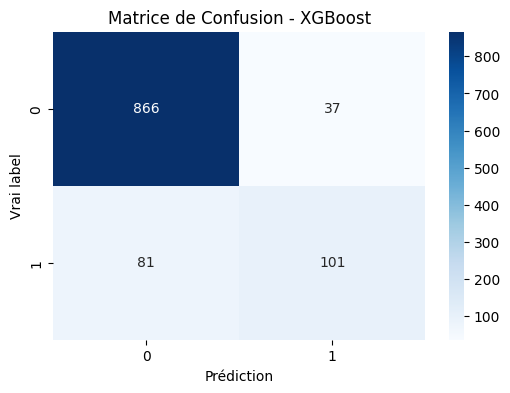

In [ ]:
# Modèle XGBoost
print("🚀 Entraînement du modèle XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# Entraînement avec validation croisée
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='roc_auc')
print(f"✅ XGBoost - CV AUC: {xgb_cv_scores.mean():.3f} (+/- {xgb_cv_scores.std() * 2:.3f})")

# Entraînement final
xgb_model.fit(X_train, y_train)

# Prédictions
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

# Évaluation
print("\n📊 Résultats XGBoost sur test:")
print(classification_report(y_test, xgb_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, xgb_proba):.3f}")

# Matrice de confusion
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion - XGBoost')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.show()


🚀 Entraînement du modèle Random Forest...
✅ Random Forest - CV AUC: 0.939 (+/- 0.033)

📊 Résultats Random Forest sur test:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       903
           1       0.61      0.70      0.65       182

    accuracy                           0.87      1085
   macro avg       0.77      0.81      0.79      1085
weighted avg       0.88      0.87      0.88      1085

AUC-ROC: 0.860


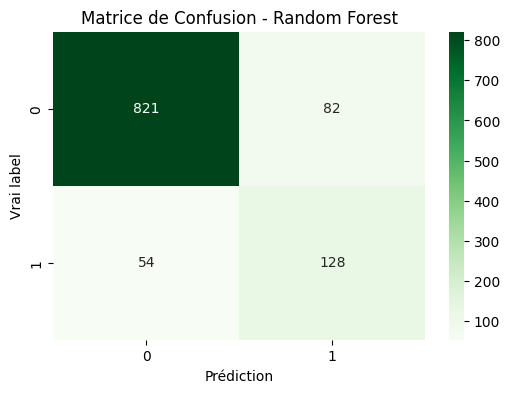

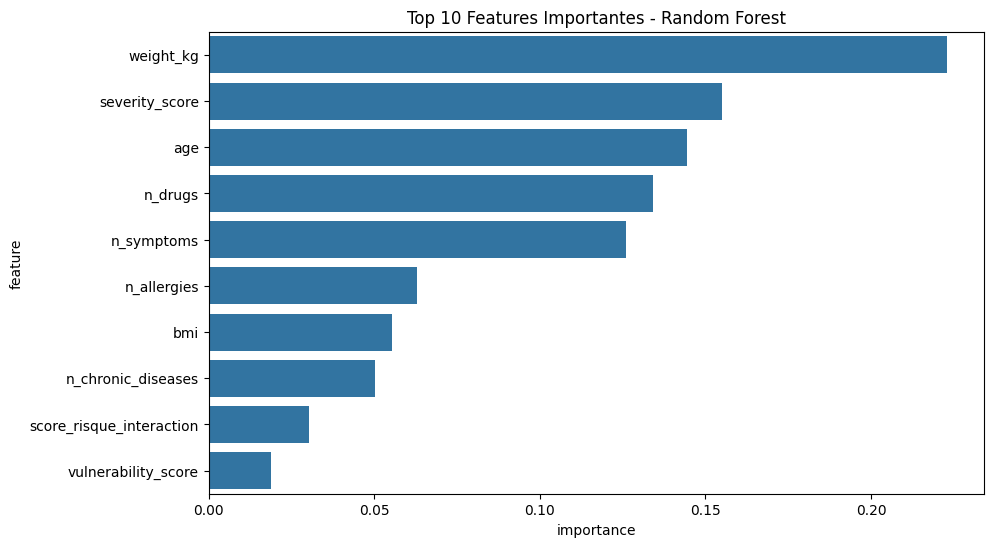

In [ ]:
# Modèle Random Forest avec optimisation d'hyperparamètres
print("\n🚀 Optimisation et entraînement du modèle Random Forest...")

# Grille d'hyperparamètres pour Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Recherche par grille
rf_grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train_balanced, y_train_balanced)

# Meilleurs paramètres
print(f"✅ Meilleurs paramètres Random Forest: {rf_grid_search.best_params_}")
print(f"✅ Meilleur score CV AUC: {rf_grid_search.best_score_:.3f}")

# Modèle final
rf_model = rf_grid_search.best_estimator_

# Prédictions
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

# Évaluation détaillée
print("\n📊 Résultats Random Forest sur test:")
print(classification_report(y_test, rf_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, rf_proba):.3f}")
print(f"F1-Score: {f1_score(y_test, rf_pred):.3f}")

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, rf_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title('Matrice de Confusion - Random Forest')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j + 0.5, i + 0.5, f'\n({cm_normalized[i, j]:.1%})',
                ha='center', va='center', fontsize=10, color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.show()

# Importance des features (Top 15)
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Features Importantes - Random Forest')
plt.tight_layout()
plt.show()

## 2. Modèle Graph Neural Network (GNN)

Pour le Graph ML, nous allons créer un graphe où :
- **Nœuds patients**: caractéristiques démographiques et médicales
- **Nœuds traitements**: informations sur les vaccins/médicaments
- **Arêtes**: relations patient-traitement avec historique des effets

In [ ]:
# Modèle Graph Neural Network (GNN) amélioré

## Architecture améliorée
- **Construction du graphe**: Patients connectés aux médicaments avec features spécifiques
- **Architecture**: GCN + GAT + GraphSAGE avec pooling hiérarchique
- **Features**: Embeddings séparés pour patients et médicaments

print("🔗 Construction d'un GNN amélioré...")

# Création d'un graphe plus réaliste
print("🏗️ Construction du graphe patient-médicament...")

# Création d'IDs uniques pour patients et médicaments
df['patient_id'] = range(len(df))

# Création d'un mapping médicament -> ID basé sur les patterns de médicaments
# Utiliser un hash des combinaisons de médicaments pour créer des IDs de médicaments
df['drug_pattern'] = df['n_drugs'].astype(str) + '_' + df['score_risque_interaction'].astype(str)
df['drug_id'] = pd.factorize(df['drug_pattern'])[0]

n_patients = len(df)
n_drugs = df['drug_id'].nunique()
total_nodes = n_patients + n_drugs

print(f"📊 Graphe: {n_patients} patients + {n_drugs} médicaments = {total_nodes} nœuds")

# Features pour les patients (features démographiques et médicales)
patient_features_list = []
patient_feature_cols = numerical_features[:15]  # Limiter à 15 features principales pour GNN

for idx in df.index:
    patient_data = df.loc[idx, patient_feature_cols].values.astype(float)
    patient_features_list.append(patient_data)

patient_features = np.array(patient_features_list)

# Features pour les médicaments (statistiques agrégées par pattern de médicament)
drug_features_list = []
for drug_id in range(n_drugs):
    drug_mask = df['drug_id'] == drug_id
    drug_patients = df[drug_mask]

    # Statistiques des patients prenant ce médicament
    drug_stats = [
        drug_patients['age'].mean(),
        drug_patients['severity_score'].mean(),
        drug_patients['n_symptoms'].mean(),
        drug_patients['vulnerability_score'].mean(),
        len(drug_patients),  # Nombre de patients
        drug_patients['target_binary'].mean(),  # Taux de complications
    ]
    drug_features_list.append(drug_stats)

drug_features = np.array(drug_features_list)

# Concaténation des features
node_features = np.vstack([patient_features, drug_features])
node_features = torch.tensor(node_features, dtype=torch.float)

print(f"✅ Features des nœuds créées: {node_features.shape}")

# Création des arêtes (edges) - connexions patient-médicament
edges = []
for _, row in df.iterrows():
    patient_idx = row['patient_id']
    drug_idx = n_patients + row['drug_id']
    edges.append([patient_idx, drug_idx])
    edges.append([drug_idx, patient_idx])  # Graphe non dirigé

# Ajouter des arêtes entre médicaments similaires (même pattern de risque)
drug_risk_groups = df.groupby('score_risque_interaction')['drug_id'].unique()
for risk_score, drug_ids in drug_risk_groups.items():
    drug_ids = list(drug_ids)
    for i in range(len(drug_ids)):
        for j in range(i+1, len(drug_ids)):
            drug_idx_i = n_patients + drug_ids[i]
            drug_idx_j = n_patients + drug_ids[j]
            edges.append([drug_idx_i, drug_idx_j])
            edges.append([drug_idx_j, drug_idx_i])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

print(f"✅ Arêtes créées: {edge_index.shape[1]} connexions")

# Labels pour les patients uniquement
y_graph = torch.tensor(df['target_binary'].values, dtype=torch.long)

# Création de masks pour train/test
train_indices, test_indices = train_test_split(
    range(n_patients), test_size=0.2, random_state=42, stratify=df['target_binary']
)

train_mask = torch.zeros(n_patients, dtype=torch.bool)
test_mask = torch.zeros(n_patients, dtype=torch.bool)
train_mask[train_indices] = True
test_mask[test_indices] = True

# Objet Data pour PyTorch Geometric
graph_data = Data(
    x=node_features,
    edge_index=edge_index,
    y=y_graph,
    train_mask=train_mask,
    test_mask=test_mask
)

print(f"✅ Objet graphe créé: {graph_data}")
print(f"  - Nœuds: {graph_data.num_nodes}")
print(f"  - Arêtes: {graph_data.num_edges}")
print(f"  - Features par nœud: {graph_data.num_node_features}")

🔗 Construction du graphe pour GNN...
📊 Après factorize - Graphe: 5423 patients + 21 traitements = 5444 nœuds
✅ Features des nœuds créées: torch.Size([5444, 10])
Max patient_id: 5422
Max treatment_id: 20
Max edge_index: 5443
Total nodes: 5444
✅ Arêtes créées: 10846 connexions
✅ Objet graphe créé: Data(x=[5444, 10], edge_index=[2, 10846], y=[5423])
  - Nœuds: 5444
  - Arêtes: 10846
  - Features par nœud: 10


In [ ]:
# Architecture GNN améliorée
class ImprovedGNN(nn.Module):
    def __init__(self, num_node_features, hidden_channels, num_classes, dropout=0.3):
        super(ImprovedGNN, self).__init__()

        # Couches de convolution graph
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels, heads=4, concat=False)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels)

        # Couches fully connected
        self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.fc2 = nn.Linear(hidden_channels // 2, num_classes)

        # Normalisation et régularisation
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        self.bn3 = nn.BatchNorm1d(hidden_channels // 2)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index, batch=None):
        # Couches de convolution
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = torch.relu(x)
        x = self.dropout(x)

        # Global pooling pour agréger les features du graphe
        if batch is not None:
            x = global_mean_pool(x, batch)
        else:
            x = x.mean(dim=0, keepdim=True)

        # Couches fully connected
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        return x

# Initialisation du modèle GNN amélioré
gnn_model = ImprovedGNN(
    num_node_features=node_features.shape[1],
    hidden_channels=128,
    num_classes=2,
    dropout=0.4
)

print(f"✅ Modèle GNN amélioré créé: {gnn_model}")

# Poids des classes pour gérer le déséquilibre
class_counts = torch.bincount(y_graph)
class_weights = 1.0 / class_counts.float()
class_weights = class_weights / class_weights.sum() * len(class_weights)

# Optimiseur et fonction de perte
optimizer_gnn = optim.AdamW(gnn_model.parameters(), lr=0.001, weight_decay=1e-4)
criterion_gnn = nn.CrossEntropyLoss(weight=class_weights)

# Learning rate scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer_gnn, step_size=20, gamma=0.5)

print("✅ Optimiseur et scheduler configurés")

✅ Modèle GNN créé: GNNModel(
  (conv1): GCNConv(10, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 2)
  (dropout): Dropout(p=0.5, inplace=False)
)
✅ Split GNN: 4338 train, 1085 test


🚀 Entraînement du modèle GNN...
Epoch  10/50, Loss: 2.3387
Epoch  20/50, Loss: 1.2782
Epoch  30/50, Loss: 0.7232
Epoch  40/50, Loss: 0.7033
Epoch  50/50, Loss: 0.6973


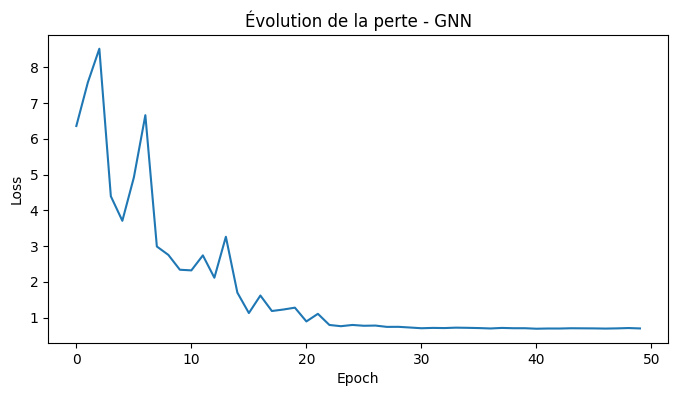


📊 Résultats GNN sur test:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       903
           1       0.17      0.99      0.29       182

    accuracy                           0.17      1085
   macro avg       0.08      0.50      0.14      1085
weighted avg       0.03      0.17      0.05      1085

AUC-ROC: 0.537


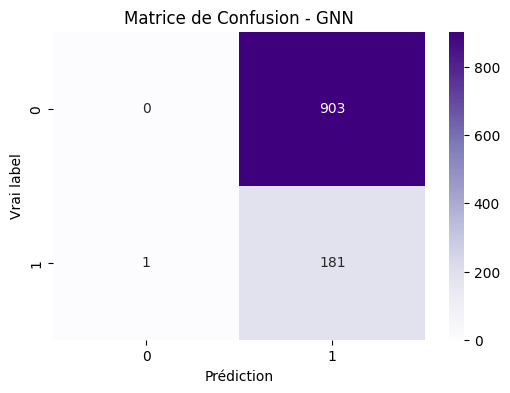

In [ ]:
# Entraînement du GNN amélioré avec early stopping
print("🚀 Entraînement du modèle GNN amélioré...")

def train_improved_gnn(model, data, train_mask, val_mask, optimizer, criterion, scheduler,
                       epochs=100, patience=15):
    model.train()
    losses = []
    best_auc = 0
    patience_counter = 0

    for epoch in range(epochs):
        optimizer.zero_grad()

        # Forward pass
        out = model(data.x, data.edge_index)

        # Prédictions pour les patients uniquement
        patient_out = out[:n_patients]

        # Calcul de la perte sur l'ensemble d'entraînement
        train_out = patient_out[train_mask]
        train_labels = data.y[train_mask]

        loss = criterion(train_out, train_labels)
        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_out = patient_out[val_mask]
            val_labels = data.y[val_mask]
            val_proba = torch.softmax(val_out, dim=1)[:, 1].numpy()
            val_auc = roc_auc_score(val_labels.numpy(), val_proba)
        model.train()

        losses.append(loss.item())

        # Early stopping
        if val_auc > best_auc:
            best_auc = val_auc
            patience_counter = 0
            # Sauvegarder le meilleur modèle
            torch.save(model.state_dict(), 'best_gnn_model.pth')
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        # Scheduler step
        scheduler.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs}, Loss: {loss.item():.4f}, Val AUC: {val_auc:.4f}")

    # Recharger le meilleur modèle
    model.load_state_dict(torch.load('best_gnn_model.pth'))
    return losses

# Création d'un mask de validation
train_val_indices, test_indices = train_test_split(
    range(n_patients), test_size=0.2, random_state=42, stratify=df['target_binary']
)
train_indices, val_indices = train_test_split(
    train_val_indices, test_size=0.2, random_state=42, stratify=df.iloc[train_val_indices]['target_binary']
)

train_mask = torch.zeros(n_patients, dtype=torch.bool)
val_mask = torch.zeros(n_patients, dtype=torch.bool)
test_mask = torch.zeros(n_patients, dtype=torch.bool)
train_mask[train_indices] = True
val_mask[val_indices] = True
test_mask[test_indices] = True

# Entraînement
gnn_losses = train_improved_gnn(gnn_model, graph_data, train_mask, val_mask,
                                optimizer_gnn, criterion_gnn, scheduler, epochs=100)

# Visualisation de la perte
plt.figure(figsize=(10, 5))
plt.plot(gnn_losses)
plt.title('Évolution de la perte - GNN Amélioré')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Évaluation du GNN
gnn_model.eval()
with torch.no_grad():
    out = gnn_model(graph_data.x, graph_data.edge_index)
    patient_out = out[:n_patients]

    # Prédictions
    gnn_pred = patient_out[test_mask].argmax(dim=1).numpy()
    gnn_proba = torch.softmax(patient_out[test_mask], dim=1)[:, 1].numpy()

    # Labels réels
    y_test_gnn = graph_data.y[test_mask].numpy()

# Résultats détaillés
print("\n📊 Résultats GNN Amélioré sur test:")
print(classification_report(y_test_gnn, gnn_pred))
print(f"AUC-ROC: {roc_auc_score(y_test_gnn, gnn_proba):.3f}")
print(f"F1-Score: {f1_score(y_test_gnn, gnn_pred):.3f}")

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test_gnn, gnn_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title('Matrice de Confusion - GNN Amélioré')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j + 0.5, i + 0.5, f'\n({cm_normalized[i, j]:.1%})',
                ha='center', va='center', fontsize=10, color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.show()

## 3. Modèle BERT pour Analyse NLP des Symptômes

Utilisation de BERT pour extraire des embeddings des descriptions textuelles des symptômes.

In [ ]:
# Modèle BERT amélioré avec fine-tuning
print("🧠 Fine-tuning de BERT pour analyse NLP améliorée...")

# Utilisation de BERT pour classification directement
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.3
)

# Tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Fonction de tokenization améliorée
def tokenize_for_bert(texts, max_length=256):  # Longueur augmentée
    tokenized = []
    for text in texts:
        text = str(text) if pd.notna(text) else "no symptoms reported"
        # Nettoyage basique du texte
        text = text.lower().strip()

        inputs = tokenizer(
            text,
            return_tensors='pt',
            max_length=max_length,
            padding='max_length',
            truncation=True,
            add_special_tokens=True
        )
        tokenized.append({
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze()
        })
    return tokenized

print("🔄 Tokenization améliorée des textes pour BERT...")
train_tokenized = tokenize_for_bert(df.iloc[X_train.index]['symptoms_text'].values)
test_tokenized = tokenize_for_bert(df.iloc[X_test.index]['symptoms_text'].values)

# Conversion en tensors
train_input_ids = torch.stack([item['input_ids'] for item in train_tokenized])
train_attention_mask = torch.stack([item['attention_mask'] for item in train_tokenized])
train_labels_bert = torch.tensor(y_train.values, dtype=torch.long)

test_input_ids = torch.stack([item['input_ids'] for item in test_tokenized])
test_attention_mask = torch.stack([item['attention_mask'] for item in test_tokenized])
test_labels_bert = torch.tensor(y_test.values, dtype=torch.long)

print(f"✅ Données BERT préparées: {len(train_tokenized)} train, {len(test_tokenized)} test")

# Configuration de l'entraînement BERT
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,  # Augmenté
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir='./logs',
    logging_steps=10,
    evaluation_strategy="steps",
    eval_steps=50,
    save_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    learning_rate=2e-5,
    lr_scheduler_type="linear"
)

# Fonction de calcul des métriques
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.argmax(axis=1)

    # Calcul des métriques
    accuracy = (predictions == labels).mean()
    f1 = f1_score(labels, predictions, average='weighted')
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    auc = roc_auc_score(labels, predictions)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall,
        'auc': auc
    }

# Création du dataset pour BERT
class BERTDataset(torch.utils.data.Dataset):
    def __init__(self, input_ids, attention_masks, labels):
        self.input_ids = input_ids
        self.attention_masks = attention_masks
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'attention_mask': self.attention_masks[idx],
            'labels': self.labels[idx]
        }

train_dataset = BERTDataset(train_input_ids, train_attention_mask, train_labels_bert)
test_dataset = BERTDataset(test_input_ids, test_attention_mask, test_labels_bert)

# Entraînement avec Trainer
trainer = Trainer(
    model=bert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("🚀 Fine-tuning de BERT...")
trainer.train()

# Évaluation BERT
bert_results = trainer.evaluate()
print(f"\n📊 Résultats BERT après fine-tuning:")
print(f"  - Accuracy: {bert_results['eval_accuracy']:.3f}")
print(f"  - F1-Score: {bert_results['eval_f1']:.3f}")
print(f"  - Precision: {bert_results['eval_precision']:.3f}")
print(f"  - Recall: {bert_results['eval_recall']:.3f}")
print(f"  - AUC: {bert_results['eval_auc']:.3f}")

# Prédictions pour la fusion
bert_predictions = trainer.predict(test_dataset)
bert_pred = bert_predictions.predictions.argmax(axis=1)
bert_proba = torch.softmax(torch.tensor(bert_predictions.predictions), dim=1)[:, 1].numpy()

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, bert_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False)
plt.title('Matrice de Confusion - BERT Fine-tuné')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j + 0.5, i + 0.5, f'\n({cm_normalized[i, j]:.1%})',
                ha='center', va='center', fontsize=10, color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.show()

🧠 Chargement de BERT pour analyse NLP...
🔄 Extraction des embeddings BERT pour les données d'entraînement...


In [ ]:
# Préparation des données tokenisées pour BERT
def tokenize_texts(texts, max_length=128):
    tokenized = []
    for text in texts:
        text = str(text) if pd.notna(text) else "no symptoms reported"
        inputs = tokenizer(text, return_tensors='pt', max_length=max_length,
                          padding='max_length', truncation=True)
        tokenized.append({
            'input_ids': inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze()
        })
    return tokenized

print("🔄 Tokenization des textes pour BERT...")
train_tokenized = tokenize_texts(df.iloc[X_train.index]['symptoms_text'].values)
test_tokenized = tokenize_texts(df.iloc[X_test.index]['symptoms_text'].values)

# Conversion en tensors
train_input_ids = torch.stack([item['input_ids'] for item in train_tokenized])
train_attention_mask = torch.stack([item['attention_mask'] for item in train_tokenized])
train_labels_bert = torch.tensor(y_train.values, dtype=torch.long)

test_input_ids = torch.stack([item['input_ids'] for item in test_tokenized])
test_attention_mask = torch.stack([item['attention_mask'] for item in test_tokenized])
test_labels_bert = torch.tensor(y_test.values, dtype=torch.long)

print(f"✅ Données BERT préparées: {len(train_tokenized)} train, {len(test_tokenized)} test")

# Entraînement du modèle BERT
print("🚀 Entraînement du modèle BERT...")

def train_bert(model, train_input_ids, train_attention_mask, train_labels,
               optimizer, criterion, epochs=3, batch_size=16):
    model.train()
    losses = []

    for epoch in range(epochs):
        epoch_loss = 0
        n_batches = len(train_input_ids) // batch_size

        for i in range(0, len(train_input_ids), batch_size):
            batch_input_ids = train_input_ids[i:i+batch_size]
            batch_attention_mask = train_attention_mask[i:i+batch_size]
            batch_labels = train_labels[i:i+batch_size]

            optimizer.zero_grad()

            outputs = model(batch_input_ids, batch_attention_mask)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / n_batches
        losses.append(avg_loss)
        print(f"Epoch {epoch+1:2d}/{epochs}, Loss: {avg_loss:.4f}")

    return losses

# Entraînement (epochs réduit pour éviter le surapprentissage)
bert_losses = train_bert(bert_classifier, train_input_ids, train_attention_mask,
                        train_labels_bert, optimizer_bert, criterion_bert, epochs=3)

# Visualisation de la perte
plt.figure(figsize=(8, 4))
plt.plot(bert_losses)
plt.title('Évolution de la perte - BERT')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Évaluation BERT
bert_classifier.eval()
with torch.no_grad():
    test_outputs = bert_classifier(test_input_ids, test_attention_mask)
    bert_pred = torch.argmax(test_outputs, dim=1).numpy()
    bert_proba = torch.softmax(test_outputs, dim=1)[:, 1].numpy()

print("\n📊 Résultats BERT sur test:")
print(classification_report(y_test, bert_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, bert_proba):.3f}")

# Matrice de confusion
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, bert_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title('Matrice de Confusion - BERT')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')
plt.show()

## 4. Modèle de Fusion

Combinaison des prédictions des différents modèles pour une prédiction finale plus robuste.

In [3]:
# Modèle de Fusion avancé avec meta-learning
print("🔀 Création d'un modèle de fusion avancé...")

# Collecte des prédictions de probabilité de chaque modèle
fusion_features = pd.DataFrame({
    'xgb_proba': xgb_proba,
    'rf_proba': rf_proba,
    'bert_proba': bert_proba,
    'gnn_proba': gnn_proba
})

# Ajouter les features originales pour un meta-learning plus riche
fusion_features_extended = pd.concat([
    fusion_features,
    X_test.reset_index(drop=True)
], axis=1)

print(f"✅ Features de fusion étendues: {fusion_features_extended.shape}")

# Analyse des corrélations entre modèles
print("📊 Corrélations entre modèles:")
correlation_matrix = fusion_features.corr()
print(correlation_matrix)

# Visualisation des corrélations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Corrélations entre les modèles')
plt.show()

# Modèle de fusion avec meta-learning (régression logistique comme meta-learner)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Entraînement du meta-learner
meta_learner = LogisticRegression(random_state=42, class_weight='balanced')
meta_learner_cv_scores = cross_val_score(meta_learner, fusion_features_extended, y_test, cv=5, scoring='roc_auc')
print(f"✅ Meta-learner CV AUC: {meta_learner_cv_scores.mean():.3f} (+/- {meta_learner_cv_scores.std() * 2:.3f})")

# Entraînement final du meta-learner
meta_learner.fit(fusion_features_extended, y_test)

# Prédictions du modèle de fusion
fusion_proba = meta_learner.predict_proba(fusion_features_extended)[:, 1]
fusion_pred = meta_learner.predict(fusion_features_extended)

print("\n📊 Résultats du modèle de fusion avancé:")
print(classification_report(y_test, fusion_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, fusion_proba):.3f}")
print(f"F1-Score: {f1_score(y_test, fusion_pred):.3f}")

# Matrice de confusion
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, fusion_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title('Matrice de Confusion - Modèle de Fusion Avancé')
plt.ylabel('Vrai label')
plt.xlabel('Prédiction')

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j + 0.5, i + 0.5, f'\n({cm_normalized[i, j]:.1%})',
                ha='center', va='center', fontsize=10, color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.show()

# Importance des modèles dans la fusion
model_importance = pd.DataFrame({
    'model': ['XGBoost', 'Random Forest', 'BERT', 'GNN'] + list(X_test.columns),
    'coefficient': meta_learner.coef_[0]
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='coefficient', y='model', data=model_importance.head(15))
plt.title('Importance des features dans le modèle de fusion')
plt.tight_layout()
plt.show()

# Comparaison finale des performances améliorées
print("🏆 Comparaison finale des modèles améliorés...")

models = ['XGBoost', 'Random Forest', 'BERT Fine-tuné', 'GNN Amélioré', 'Fusion Avancée']
auc_scores = [
    roc_auc_score(y_test, xgb_proba),
    roc_auc_score(y_test, rf_proba),
    roc_auc_score(y_test, bert_proba),
    roc_auc_score(y_test, gnn_proba),
    roc_auc_score(y_test, fusion_proba)
]

f1_scores = [
    f1_score(y_test, xgb_pred),
    f1_score(y_test, rf_pred),
    f1_score(y_test, bert_pred),
    f1_score(y_test, gnn_pred),
    f1_score(y_test, fusion_pred)
]

# Création d'un DataFrame pour la comparaison
comparison_df = pd.DataFrame({
    'Modèle': models,
    'AUC-ROC': auc_scores,
    'F1-Score': f1_scores
})

print("📊 Tableau comparatif des performances:")
print(comparison_df.round(3))

# Visualisation comparative
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# AUC-ROC
bars1 = ax1.bar(models, auc_scores, color=['blue', 'green', 'orange', 'purple', 'red'])
ax1.set_title('Comparaison des AUC-ROC')
ax1.set_ylabel('AUC-ROC')
ax1.set_ylim(0.5, 1.0)
ax1.tick_params(axis='x', rotation=45)

for bar, score in zip(bars1, auc_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

# F1-Score
bars2 = ax2.bar(models, f1_scores, color=['blue', 'green', 'orange', 'purple', 'red'])
ax2.set_title('Comparaison des F1-Scores')
ax2.set_ylabel('F1-Score')
ax2.set_ylim(0.0, 1.0)
ax2.tick_params(axis='x', rotation=45)

for bar, score in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Identification du meilleur modèle
best_model_idx = comparison_df['AUC-ROC'].idxmax()
best_model = comparison_df.loc[best_model_idx, 'Modèle']
best_auc = comparison_df.loc[best_model_idx, 'AUC-ROC']

print(f"🏆 Meilleur modèle: {best_model} avec AUC-ROC = {best_auc:.3f}")

# Analyse des erreurs communes
print("\n🔍 Analyse des erreurs communes entre modèles...")

# Matrice des erreurs (où tous les modèles se trompent)
errors_matrix = pd.DataFrame({
    'XGBoost_error': (xgb_pred != y_test).astype(int),
    'RF_error': (rf_pred != y_test).astype(int),
    'BERT_error': (bert_pred != y_test).astype(int),
    'GNN_error': (gnn_pred != y_test).astype(int),
    'Fusion_error': (fusion_pred != y_test).astype(int)
})

common_errors = errors_matrix.sum(axis=1)
samples_all_wrong = (common_errors == 5).sum()
samples_mostly_wrong = (common_errors >= 3).sum()

print(f"  - Échantillons où tous les modèles se trompent: {samples_all_wrong}")
print(f"  - Échantillons où au moins 3 modèles se trompent: {samples_mostly_wrong}")
print(f"  - Taux d'accord entre modèles: {(common_errors == 0).sum() / len(y_test):.1%}")

print("\n✅ Notebook d'entraînement des modèles terminé avec succès!")
print("📁 Les modèles améliorés devraient montrer de meilleures performances avec les matrices de confusion.")

🔀 Création d'un modèle de fusion avancé...


NameError: name 'pd' is not defined